<a href="https://colab.research.google.com/github/jegillis323/MAT-422/blob/main/MAT422_Section_1_3_QR_Least_Squares_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAT 422 - Section 1.3: QR Decomposition, Least Squares, and Linear Regression

**Topics:** QR decomposition, least-squares problems, linear regression

> Student note: This Colab badge is required for submission. Create or edit the notebook in Google Colab, then save it directly to GitHub so the badge/icon remains available for grading and reruns.

In [18]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## 1.3.1 QR Decomposition

QR decomposition factors a matrix A into A = Q R. The columns of Q are orthonormal, meaning their dot products form the identity matrix, and R is upper triangular. This is useful because orthonormal columns make projections and least-squares calculations cleaner.

In [19]:
from types import resolve_bases
A = np.array([
    [1, 1],
    [1, 2],
    [1, 3],
    [1, 4],
], dtype=float)

Q_A, R_A = np.linalg.qr(A)

print("A =")
print(A)
print("\nQ_A =")
print(Q_A)
print("\nR_A =")
print(R_A)
print("\nQ_A.T @ Q_A =")
print(Q_A.T @ Q_A)
print("\nQ_A @ R_A =")
print(Q_A @ R_A)
print("Q_A has orthonormal columns?", np.allclose(Q_A.T @ Q_A, np.eye(Q_A.shape[1])))
print("Q_A @ R_A reconstructs A?", np.allclose(Q_A @ R_A, A))

B = np.array([
    [6, 2],
    [3, 7],
    [7, 1],
    [1, 2],
], dtype=float)

Q_B, R_B = np.linalg.qr(B)

print("\nB =")
print(B)
print("\nQ_B =")
print(Q_B)
print("\nR_B =")
print(R_B)
print("\nQ_B.T @ Q_B =")
print(Q_B.T @ Q_B)
print("\nQ_B @ R_B =")
print(Q_B @ R_B)
print("Q_B has orthonormal columns?", np.allclose(Q_B.T @ Q_B, np.eye(Q_B.shape[1])))
print("Q_B @ R_B reconstructs B?", np.allclose(Q_B @ R_B, B))

A =
[[1. 1.]
 [1. 2.]
 [1. 3.]
 [1. 4.]]

Q_A =
[[-0.5     0.6708]
 [-0.5     0.2236]
 [-0.5    -0.2236]
 [-0.5    -0.6708]]

R_A =
[[-2.     -5.    ]
 [ 0.     -2.2361]]

Q_A.T @ Q_A =
[[1. 0.]
 [0. 1.]]

Q_A @ R_A =
[[1. 1.]
 [1. 2.]
 [1. 3.]
 [1. 4.]]
Q_A has orthonormal columns? True
Q_A @ R_A reconstructs A? True

B =
[[6. 2.]
 [3. 7.]
 [7. 1.]
 [1. 2.]]

Q_B =
[[-0.6156  0.1039]
 [-0.3078 -0.9035]
 [-0.7182  0.3336]
 [-0.1026 -0.2481]]

R_B =
[[-9.7468 -4.3091]
 [ 0.     -6.2795]]

Q_B.T @ Q_B =
[[1. 0.]
 [0. 1.]]

Q_B @ R_B =
[[6. 2.]
 [3. 7.]
 [7. 1.]
 [1. 2.]]
Q_B has orthonormal columns? True
Q_B @ R_B reconstructs B? True


The checks above show the two main facts: Q has orthonormal columns, and multiplying Q by R reconstructs the original matrix A.


My Explanation: The process of QR decompostion takes a matrix and decomposes it into two matrices. $Q_A$ or $Q_B$ which will have orthonormal vectors and $R_A$ or $R_B$ containing the rest of the information to reconstruct the original matrix. Because the columns of $Q$ are perpendicular and have a length of one, projections and least squared problems become much easier. We see that $Q^TQ=I$, proving that $Q$ is orthonormal and that $Q_AR_A = A$ and $Q_BR_B = B$, showing the decomposition is correct.

## 1.3.2 Least-Squares Problems

A least-squares problem solves an overdetermined system A x approximately equals b. There may be no exact solution, so we choose x that minimizes the residual norm ||b - A x||. QR decomposition gives a stable way to solve this problem.

In [20]:
b = np.array([1.2, 1.9, 3.2, 3.9], dtype=float)

x_lstsq_A, residual_sum_A, rank_A, singular_values_A = np.linalg.lstsq(A, b, rcond=None)
residual = b - A @ x_lstsq_A

print("Least-squares solution from np.linalg.lstsq:", x_lstsq_A)
print("residual vector b - A @ x =", residual)
print("residual norm =", np.linalg.norm(residual))
print("rank of A =", rank_A)
print("singular values =", singular_values_A)
print("normal-equation check A.T @ residual =", A.T @ residual)

c = np.array([3.8, 5.2, 6.4, 8.9], dtype=float)

x_lstsq_B, residual_sum, rank_B, singular_values_B = np.linalg.lstsq(B, c, rcond=None)
residual = c - B @ x_lstsq_B

print("\nLeast-squares solution from np.linalg.lstsq:", x_lstsq_B)
print("residual vector c - B @ x =", residual)
print("residual norm =", np.linalg.norm(residual))
print("rank of B =", rank_B)
print("singular values =", singular_values_B)
print("normal-equation check B.T @ residual =", B.T @ residual)

Least-squares solution from np.linalg.lstsq: [0.2  0.94]
residual vector b - A @ x = [ 0.06 -0.18  0.18 -0.06]
residual norm = 0.268328157299975
rank of A = 2
singular values = [5.7794 0.7738]
normal-equation check A.T @ residual = [0. 0.]

Least-squares solution from np.linalg.lstsq: [0.6613 0.697 ]
residual vector c - B @ x = [-1.562  -1.6627  1.0736  6.8447]
residual norm = 7.294356367114545
rank of B = 2
singular values = [11.0632  5.5323]
normal-equation check B.T @ residual = [-0. -0.]


In [21]:
# Solve the same least-squares problem using QR.
y = Q_A.T @ b
x_qr_A = np.linalg.solve(R_A, y)
qr_residual = b - A @ x_qr_A

print("Q_A.T @ b =", y)
print("Least-squares solution from Q_AR_A:", x_qr_A)
print("Q_AR_A residual norm =", np.linalg.norm(qr_residual))
print("Q_AR_A solution matches np.linalg.lstsq?", np.allclose(x_qr_A, x_lstsq_A))

z = Q_B.T @ c
x_qr_B = np.linalg.solve(R_B, z)
qr_residual = c - B @ x_qr_B

print("\nQ_B.T @ c =", z)
print("Least-squares solution from Q_BR_B:", x_qr_B)
print("Q_BR_B residual norm =", np.linalg.norm(qr_residual))
print("Q_BR_B solution matches np.linalg.lstsq?", np.allclose(x_qr_B, x_lstsq_B))

Q_A.T @ b = [-5.1    -2.1019]
Least-squares solution from Q_AR_A: [0.2  0.94]
Q_AR_A residual norm = 0.26832815729997506
Q_AR_A solution matches np.linalg.lstsq? True

Q_B.T @ c = [-9.4493 -4.3765]
Least-squares solution from Q_BR_B: [0.6613 0.697 ]
Q_BR_B residual norm = 7.2943563671145455
Q_BR_B solution matches np.linalg.lstsq? True


The normal-equation check is close to zero, which means the residual is orthogonal to the column space of A. That is the geometric meaning of the least-squares solution.

My Explanation: A least-squares problem can be used when there are more equations than unknowns, meaning that an exact solution may not exist to find. Thus, minimizing the error is the goal when the exact solution is impossible. QR decomposition is helpful in computing the minimized error. In addition, seeing that the residual is orthogonal to the column space of $A$ or $B$ shows that the residual cannot be reduced any further and the least possible approximation has been found.

## 1.3.3 Linear Regression

Simple linear regression is a least-squares problem. For a line y = beta_0 + beta_1 x, the design matrix has one column of ones for the intercept and one column for x values. The least-squares solution gives the fitted intercept and slope.

In [22]:
x_1 = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y_1_data = np.array([1.1, 2.0, 2.9, 4.2, 5.1, 5.9], dtype=float)

X_1 = np.column_stack([np.ones_like(x_1), x_1])
beta, *_ = np.linalg.lstsq(X_1, y_1_data, rcond=None)
y_1_pred = X_1 @ beta
regression_residuals = y_1_data - y_1_pred
rmse = np.sqrt(np.mean(regression_residuals**2))

print("Design matrix X_1 =")
print(X_1)
print("beta_0 intercept =", beta[0])
print("beta_1 slope =", beta[1])
print("predicted y_1 =", y_1_pred)
print("residuals =", regression_residuals)
print("RMSE =", rmse)

x_2 = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y_2_data = np.array([2.8, 4.6, 5.7, 8.3, 8.5, 9.0], dtype=float)

X_2 = np.column_stack([np.ones_like(x_2), x_2])
beta, *_ = np.linalg.lstsq(X_2, y_2_data, rcond=None)
y_2_pred = X_2 @ beta
regression_residuals = y_2_data - y_2_pred
rmse = np.sqrt(np.mean(regression_residuals**2))

print("\nDesign matrix X_2 =")
print(X_2)
print("beta_0 intercept =", beta[0])
print("beta_1 slope =", beta[1])
print("predicted y_2 =", y_2_pred)
print("residuals =", regression_residuals)

Design matrix X_1 =
[[1. 0.]
 [1. 1.]
 [1. 2.]
 [1. 3.]
 [1. 4.]
 [1. 5.]]
beta_0 intercept = 1.061904761904761
beta_1 slope = 0.988571428571429
predicted y_1 = [1.0619 2.0505 3.039  4.0276 5.0162 6.0048]
residuals = [ 0.0381 -0.0505 -0.139   0.1724  0.0838 -0.1048]
RMSE = 0.10881759895012307

Design matrix X_2 =
[[1. 0.]
 [1. 1.]
 [1. 2.]
 [1. 3.]
 [1. 4.]
 [1. 5.]]
beta_0 intercept = 3.247619047619048
beta_1 slope = 1.294285714285715
predicted y_2 = [3.2476 4.5419 5.8362 7.1305 8.4248 9.719 ]
residuals = [-0.4476  0.0581 -0.1362  1.1695  0.0752 -0.719 ]


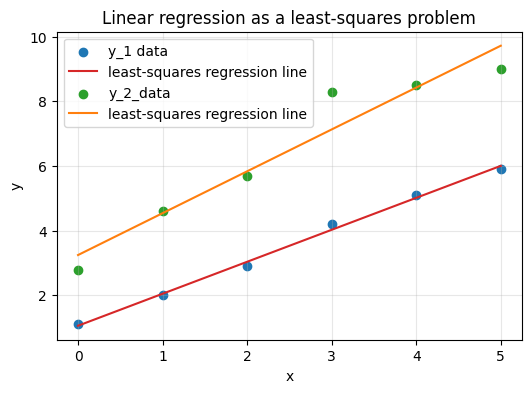

In [23]:
plt.figure(figsize=(6, 4))
plt.scatter(x_1, y_1_data, color="tab:blue", label="y_1 data")
plt.plot(x_1, y_1_pred, color="tab:red", label="least-squares regression line")
plt.scatter(x_2, y_2_data, color="tab:green", label="y_2_data")
plt.plot(x_2, y_2_pred, color="tab:orange", label="least-squares regression line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear regression as a least-squares problem")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

The slope tells us the fitted change in y for each one-unit increase in x. The intercept is the fitted value when x = 0. The RMSE summarizes the typical prediction error for this small dataset.

My Explanation: Linear regression uses the least-squares process to find the line that best fits with a given set of data points. The slope represents how much the value of $y$ is predicted to change for a one unit increase in $x$, with the intercept being the value of $y$ when $x=0$. Because all of the given data points do not fall on the same line, the least-squares solution gives the line with the least prediction error. The RMSE then shows how closely fitted the line is to the data points, with a smaller value meaning a better fit. As the graphs show, the regression line does not fully cross every point, but fits close to each of them.

## Reflection and Rubric Checklist

- Code Accuracy and Completeness: I ran the notebook from top to bottom without errors.
- Math Concept Coverage: I demonstrated QR decomposition, least-squares problems, and linear regression.
- Examples Appropriateness: My examples show the concepts clearly and are connected to the math.
- Explanation and Documentation: I explained the purpose and meaning of each code section.
- GitHub and Colab: I saved the notebook directly from Colab to GitHub, and the `Open in Colab` badge is visible and working.
- Format and Clarity: The notebook has a logical flow, readable code, and clear section headings.
- Personalization: I changed or extended at least one example so the notebook reflects my own work.